In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nelpy as nel
import numpy as np
import pandas as pd

from neuro_py.ensemble.ppseq import (
    PPSeq,
    fit_ppseq_behavior_model,
    load_ppseq_songbird_spikes,
    plot_ppseq_behavior_with_position,
    plot_ppseq_diagnostics,
    plot_ppseq_raster,
    ppseq_assignment_raster,
    score_ppseq_pre_post_ripples,
    summarize_ppseq_replay_scores,
)
from neuro_py.io import loading
from neuro_py.session.locate_epochs import compress_repeated_epochs, find_pre_task_post

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


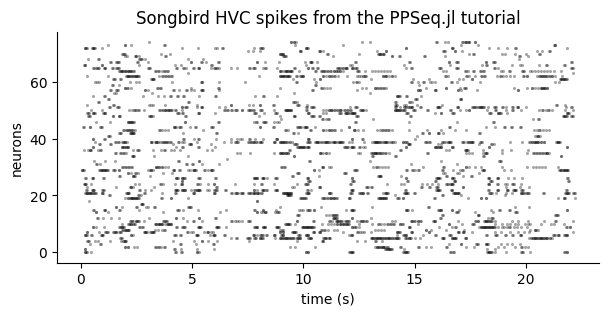

In [2]:
# Songbird PPSeq parity demo: load the same two-column spike file used by PPSeq.jl.
songbird_path = Path("tutorials/data/songbird_spikes.txt")
if not songbird_path.exists():
    songbird_path = Path("data/songbird_spikes.txt")
spike_times, neuron_ids_raw = load_ppseq_songbird_spikes(songbird_path)

# Match the Julia tutorial: randomly permute neuron labels to hide the sequences.
num_neurons = 75
rng = np.random.default_rng(0)
neuron_permutation = rng.permutation(num_neurons)
neuron_ids = neuron_permutation[neuron_ids_raw]
max_time = 22.2

fig, ax = plt.subplots(figsize=(7, 3))
plot_ppseq_raster(spike_times, neuron_ids, ax=ax)
ax.set_title("Songbird HVC spikes from the PPSeq.jl tutorial")
plt.show()

In [3]:
songbird = PPSeq(
    n_templates=2,
    template_duration=60,
    n_neurons=num_neurons,
    bin_size=0.02,
    random_state=0,
    sequence_frac=0.9,
    concentration=0.1,
    min_width_bins=1,
    max_width_bins=12,
)
songbird_result = songbird.fit(
    spike_times,
    neuron_ids=neuron_ids,
    start=0.0,
    stop=max_time,
    num_iter=60,
    init="peak_time",
)

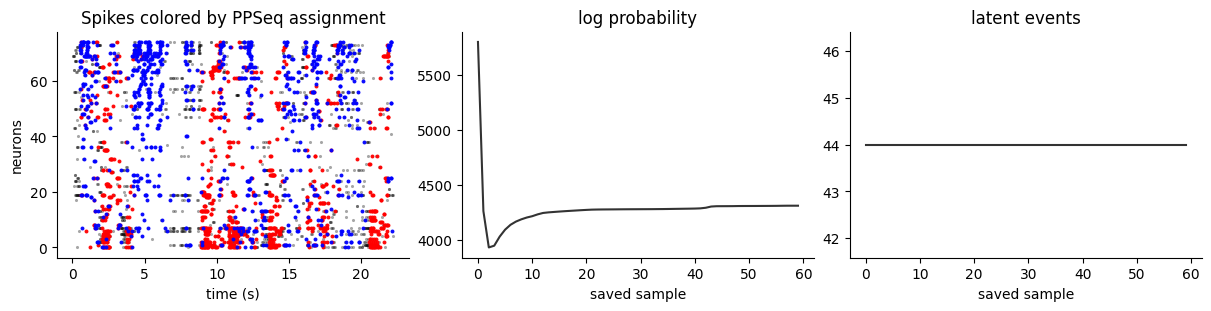

,event_id,time,template_id,amplitude,duration,log_probability
0,0,0.54,0,24.136789,1.2,0.0
1,1,0.54,1,97.279886,1.2,0.0
2,2,2.10,0,125.930887,1.2,0.0
3,3,2.10,1,18.610936,1.2,0.0
4,4,3.74,0,22.191556,1.2,0.0


In [4]:
assignments = ppseq_assignment_raster(songbird_result, threshold=0.2)
sort_order = np.argsort(songbird.template_scales_[1] - songbird.template_scales_[0])

fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
plot_ppseq_raster(
    spike_times,
    neuron_ids,
    assignments,
    sort_order=sort_order,
    ax=axes[0],
    colors=["red", "blue"],
)
axes[0].set_title("Spikes colored by PPSeq assignment")
plot_ppseq_diagnostics(songbird_result, ax=axes[1:])
plt.show()

songbird_result.events.head()

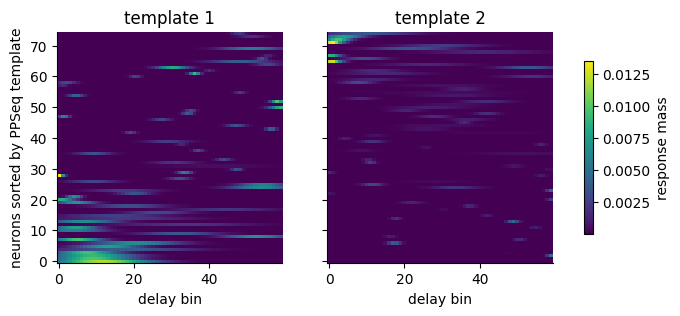

In [5]:
fig, axes = plt.subplots(1, songbird.n_templates, figsize=(8, 3), sharey=True)
axes = np.atleast_1d(axes)
for template_id, ax in enumerate(axes):
    im = ax.imshow(
        songbird.templates[template_id, sort_order],
        aspect="auto",
        origin="lower",
    )
    ax.set_title(f"template {template_id + 1}")
    ax.set_xlabel("delay bin")
axes[0].set_ylabel("neurons sorted by PPSeq template")
fig.colorbar(im, ax=axes, shrink=0.75, label="response mass")
plt.show()

In [6]:
# Simulated task and replay data
def simulate_sequences(sequence_orders, sequence_starts, *, n_neurons=75, duration=22.0, seed=0):
    rng = np.random.default_rng(seed)
    spike_times, neuron_ids, labels = [], [], []
    for neuron in range(n_neurons):
        n_background = rng.poisson(0.55 * duration)
        spike_times.extend(rng.uniform(0, duration, n_background))
        neuron_ids.extend([neuron] * n_background)
        labels.extend([-1] * n_background)
    for seq_id, starts in sequence_starts.items():
        order = np.asarray(sequence_orders[seq_id], dtype=int)
        offsets = np.linspace(0.03, 0.52, len(order))
        for start in starts:
            for neuron, offset in zip(order, offsets):
                if rng.random() < 0.86:
                    spike_times.append(start + offset + rng.normal(0, 0.012))
                    neuron_ids.append(int(neuron))
                    labels.append(seq_id)
    order = np.argsort(spike_times)
    return np.asarray(spike_times)[order], np.asarray(neuron_ids)[order], np.asarray(labels)[order]

sequence_orders = {0: np.arange(16, 46), 1: np.arange(47, 74), 2: np.arange(32, 5, -1)}
task_starts = {0: [0.8, 2.1, 4.7, 7.8, 12.2, 16.7, 20.8], 1: [1.3, 3.5, 8.6, 11.5, 14.1, 18.1], 2: [0.4, 3.9, 8.2, 14.8, 21.1]}
task_t, task_n, true_labels = simulate_sequences(sequence_orders, task_starts, seed=2)


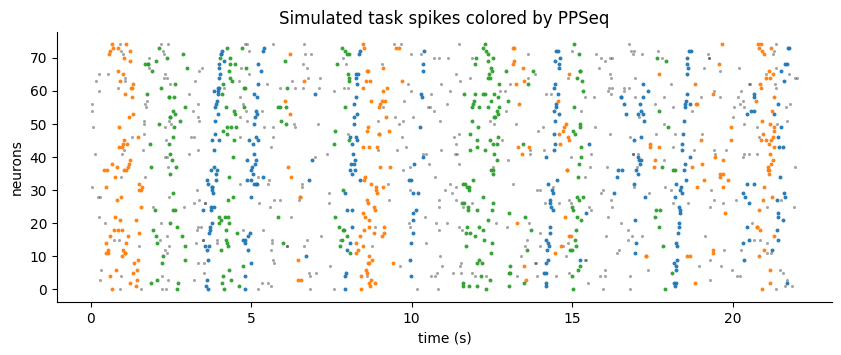

In [7]:
sim = PPSeq(3, template_duration=28, n_neurons=75, bin_size=0.02, random_state=1)
task_counts, task_centers = sim.bin_spikes(task_t, task_n, start=0, stop=22, n_neurons=75)
sim_result = sim.fit(task_t, neuron_ids=task_n, start=0, stop=22, num_iter=40)
sim_assignments = ppseq_assignment_raster(sim_result, threshold=0.3)

fig, ax = plt.subplots(figsize=(10, 3.5))
plot_ppseq_raster(task_t, task_n, sim_assignments, sort_order=np.argsort(sim.template_offsets_[0]), ax=ax)
ax.set_title("Simulated task spikes colored by PPSeq")
plt.show()


In [8]:
post_t, post_n, _ = simulate_sequences(sequence_orders, {0: [0.4], 1: [1.6], 2: [2.8]}, duration=4.0, seed=5)
control_t, control_n, _ = simulate_sequences({k: v[::-1] for k, v in sequence_orders.items()}, {0: [0.4], 1: [1.6], 2: [2.8]}, duration=4.0, seed=6)
post_counts, post_centers = sim.bin_spikes(post_t, post_n, start=0, stop=4, n_neurons=75)
control_counts, _ = sim.bin_spikes(control_t, control_n, start=0, stop=4, n_neurons=75)
intervals = np.array([[0.35, 1.0], [1.55, 2.2], [2.75, 3.4]])

post_scores = sim.score_events(post_counts, intervals, post_centers, method="per_event")
control_scores = sim.score_events(control_counts, intervals, post_centers, method="per_event")
pd.DataFrame({
    "matched_gain": post_scores["likelihood_gain"],
    "shuffled_gain": control_scores["likelihood_gain"],
})


,matched_gain,shuffled_gain
0,71.797870,87.904142
1,70.902165,20.825976
2,81.787056,99.314365


In [9]:
# Real CellExplorer / nelpy session
basepath = r"S:\data\HMC\HMC1\day8"

epochs = compress_repeated_epochs(loading.load_epoch(basepath))
# _, idx = find_pre_task_post(epochs.environment)
# pre_row, task_row, post_row = epochs.values
pre_epoch = nel.EpochArray([[epochs.iloc[0].startTime, epochs.iloc[0].stopTime]])
task_epoch = nel.EpochArray([[epochs.iloc[1].startTime, epochs.iloc[1].stopTime]])
post_epoch = nel.EpochArray([[epochs.iloc[2].startTime, epochs.iloc[2].stopTime]])
st, cell_metrics = loading.load_spikes(basepath, brainRegion="CA1", putativeCellType="Pyramidal Cell")
position = loading.load_animal_behavior(basepath)
ripples = loading.load_ripples_events(basepath)
real_available = True

In [ ]:
if real_available:
    bin_size = 0.02
    fitter = PPSeq(2, template_duration=75, n_neurons=st.n_active, bin_size=bin_size, random_state=0)
    task_counts, task_centers = fitter.bin_spikes(st[task_epoch], start=task_epoch.start, stop=task_epoch.stop)
    pos_col = "x" if "x" in position.columns else "linearized"
    pos_time = position["time"].to_numpy() if "time" in position.columns else position.index.to_numpy(dtype=float)
    task_position = np.interp(task_centers, pos_time, position[pos_col].to_numpy(dtype=float), left=np.nan, right=np.nan)
    ppseq_real, fit_result, candidates, diagnostics = fit_ppseq_behavior_model(task_counts, task_centers, task_position)
    display(candidates.head())
    display(diagnostics.summary)
else:
    ppseq_real = fit_result = candidates = diagnostics = None


In [ ]:
if real_available:
    fig, axes = plot_ppseq_behavior_with_position(ppseq_real, fit_result, st, task_epoch, position, window_s=180)
    axes[0].set_title("Task spikes colored by PPSeq assignment")
    plt.show()
else:
    pd.DataFrame(status)


In [ ]:
if real_available and diagnostics.passed:
    pre_counts, pre_centers = ppseq_real.bin_spikes(st[pre_epoch], start=pre_row.startTime, stop=pre_row.stopTime)
    post_counts, post_centers = ppseq_real.bin_spikes(st[post_epoch], start=post_row.startTime, stop=post_row.stopTime)
    all_ripples = np.column_stack([ripples.start, ripples.stop])
    pre_intervals = all_ripples[(all_ripples[:, 0] >= pre_row.startTime) & (all_ripples[:, 1] <= pre_row.stopTime)]
    post_intervals = all_ripples[(all_ripples[:, 0] >= post_row.startTime) & (all_ripples[:, 1] <= post_row.stopTime)]
    ripple_scores, null_scores, sleep_summary = score_ppseq_pre_post_ripples(ppseq_real, pre_counts, post_counts, pre_intervals, post_intervals, pre_centers, post_centers)
else:
    ripple_scores, null_scores = pd.DataFrame(), pd.DataFrame()
    sleep_summary = summarize_ppseq_replay_scores(ripple_scores)
    status.append({"level": "info", "message": "Replay not interpreted because behavioral PPSeq validation did not pass or data were unavailable."})
sleep_summary


In [ ]:
if not ripple_scores.empty:
    fig, ax = plt.subplots(figsize=(5, 3))
    ripple_scores.boxplot(column="replay_z", by="sleep_epoch", ax=ax, grid=False)
    ax.set_title("Pre/post PPSeq replay evidence")
    fig.suptitle("")
    ax.set_ylabel("replay z")
    plt.show()
else:
    pd.DataFrame(status)
